In [1]:
# Load functions
import pandas as pd
import numpy as np

from pathlib import Path

import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    average_precision_score,
    log_loss,
    brier_score_loss,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt

import joblib
import json

In [ ]:
# Helper functions to run logistic regression and evaluate performance

def build_model_form(target, features):
    return f"{target} = " + " + ".join(features)


def add_significance_stars(p_value):
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    elif p_value < 0.10:
        return "."
    else:
        return ""


def ks_statistic(y_true, y_score):
    temp = pd.DataFrame({
        "y_true": y_true,
        "y_score": y_score
    }).sort_values("y_score", ascending=False)
    temp["good"] = (temp["y_true"] == 0).astype(int)
    temp["bad"] = (temp["y_true"] == 1).astype(int)
    temp["cum_good"] = temp["good"].cumsum() / temp["good"].sum()
    temp["cum_bad"] = temp["bad"].cumsum() / temp["bad"].sum()
    return (temp["cum_bad"] - temp["cum_good"]).abs().max()


def calculate_classification_diagnostics(
    y_train,
    p_train,
    y_val,
    p_val,
    threshold=0.50
):
    def _metrics(y_true, y_score, dataset_name):
        y_pred = (y_score >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        return {
            "dataset": dataset_name,
            "threshold": threshold,
            "auc": roc_auc_score(y_true, y_score),
            "gini": 2 * roc_auc_score(y_true, y_score) - 1,
            "ks": ks_statistic(y_true, y_score),
            "pr_auc": average_precision_score(y_true, y_score),
            "log_loss": log_loss(y_true, y_score),
            "brier_score": brier_score_loss(y_true, y_score),
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "true_negative": tn,
            "false_positive": fp,
            "false_negative": fn,
            "true_positive": tp
        }
    diagnostics_df = pd.DataFrame([
        _metrics(y_train, p_train, "train"),
        _metrics(y_val, p_val, "validation")
    ])

    return diagnostics_df


def extract_coefficient_table(model):
    coef_df = pd.DataFrame({
        "variable": model.params.index,
        "coefficient": model.params.values,
        "std_error": model.bse.values,
        "z_stat": model.tvalues.values,
        "p_value": model.pvalues.values,
    })
    coef_df["significance"] = coef_df["p_value"].apply(add_significance_stars)
    coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])
    return coef_df[
        [
            "variable",
            "coefficient",
            "std_error",
            "z_stat",
            "p_value",
            "significance",
            "odds_ratio"
        ]
    ]


def calculate_vif_table(X_data):
    X_vif = sm.add_constant(X_data, has_constant="add")
    vif_rows = []
    for i, col in enumerate(X_vif.columns):
        if col == "const":
            continue
        vif_rows.append({
            "variable": col,
            "vif": variance_inflation_factor(X_vif.values, i)
        })

    return pd.DataFrame(vif_rows).sort_values("vif", ascending=False).reset_index(drop=True)



def build_formula(target, features):
    rhs = " + ".join([f'C(Q("{feature}"))' for feature in features])
    return f'{target} ~ {rhs}'


def run_binned_logistic_regression(
    model_registry,
    train_df,
    val_df,
    y_train,
    y_val,
    model_number,
    model_name,
    target,
    features,
    analyst_comments="",
    threshold=0.50,
    display_outputs=True
):
    import statsmodels.formula.api as smf

    if model_number in model_registry:
        raise ValueError(f"{model_number} already exists.")

    missing_features = [f for f in features if f not in train_df.columns]

    if missing_features:
        raise ValueError(f"Missing features: {missing_features}")

    formula = build_formula(target, features)

    model = smf.logit(
        formula=formula,
        data=train_df
    ).fit(disp=False)

    p_train = model.predict(train_df)
    p_val = model.predict(val_df)

    coefficient_table = extract_coefficient_table(model)

    diagnostics_table = calculate_classification_diagnostics(
        y_train,
        p_train,
        y_val,
        p_val,
        threshold=threshold
    )

    # VIF is not clean on raw categorical columns.
    # We calculate VIF on formula-generated design matrix instead.
    design_matrix = model.model.exog
    design_cols = model.model.exog_names

    vif_rows = []

    for i, col in enumerate(design_cols):
        if col == "Intercept":
            continue

        vif_rows.append({
            "variable": col,
            "vif": variance_inflation_factor(design_matrix, i)
        })

    vif_table = (
        pd.DataFrame(vif_rows)
        .sort_values("vif", ascending=False)
        .reset_index(drop=True)
    )

    metadata = {
        "model_number": model_number,
        "model_name": model_name,
        "model_form": formula,
        "features": features,
        "num_features": len(features),
        "aic": model.aic,
        "bic": model.bic,
        "log_likelihood": model.llf,
        "mcfadden_r2": model.prsquared,
        "threshold": threshold,
        "analyst_comments": analyst_comments
    }

    model_registry[model_number] = {
        "metadata": metadata,
        "model": model,
        "coefficients": coefficient_table,
        "diagnostics": diagnostics_table,
        "vif": vif_table
    }

    if display_outputs:
        print("=" * 100)
        print(f"{model_number}: {model_name}")
        print("=" * 100)

        print("\nMODEL FORM:")
        print(formula)

        print("\nCOEFFICIENTS:")
        display(coefficient_table)

        print("\nDIAGNOSTICS:")
        display(diagnostics_table)

        print("\nVIF:")
        display(vif_table)

    return model_registry

def export_model_registry_to_excel(
    model_registry,
    file_path
):
    with pd.ExcelWriter(file_path, engine="openpyxl") as writer:

        summary_rows = []
        for model_num, model_data in model_registry.items():
            meta = model_data["metadata"]
            diag = model_data["diagnostics"].copy()
            train_row = diag.loc[
                diag["dataset"] == "train"
            ].iloc[0]
            val_row = diag.loc[
                diag["dataset"] == "validation"
            ].iloc[0]
            summary_rows.append({
                "model_number": model_num,
                "model_name": meta["model_name"],
                "num_features": meta["num_features"],
                "aic": meta["aic"],
                "bic": meta["bic"],
                "mcfadden_r2": meta["mcfadden_r2"],
                "train_auc": train_row["auc"],
                "val_auc": val_row["auc"],
                "train_ks": train_row["ks"],
                "val_ks": val_row["ks"],
                "comments": meta["analyst_comments"]
            })
        summary_df = pd.DataFrame(summary_rows)
        summary_df.to_excel(
            writer,
            sheet_name="Summary",
            index=False
        )
        for model_num, model_data in model_registry.items():
            meta = model_data["metadata"]
            coef_df = model_data["coefficients"]
            diag_df = model_data["diagnostics"]
            vif_df = model_data["vif"]
            start_row = 0
            # Metadata
            meta_df = pd.DataFrame({
                "field": list(meta.keys()),
                "value": list(meta.values())
            })
            meta_df.to_excel(
                writer,
                sheet_name=model_num,
                startrow=start_row,
                index=False
            )
            start_row += len(meta_df) + 3

            # Coefficients
            coef_df.to_excel(
                writer,
                sheet_name=model_num,
                startrow=start_row,
                index=False
            )
            start_row += len(coef_df) + 3

            # Diagnostics
            diag_df.to_excel(
                writer,
                sheet_name=model_num,
                startrow=start_row,
                index=False
            )
            start_row += len(diag_df) + 3

            # VIF
            vif_df.to_excel(
                writer,
                sheet_name=model_num,
                startrow=start_row,
                index=False
            )

    print("Saved:", file_path)

# Gains / Lift Table

def create_gains_lift_table(y_true, y_score, dataset_name):
    temp = pd.DataFrame({
        "actual": y_true,
        "score": y_score
    })

    temp["score_decile"] = pd.qcut(
        temp["score"],
        q=10,
        labels=False,
        duplicates="drop"
    ) + 1

    gains = (
        temp.groupby("score_decile")
        .agg(
            observations=("actual", "count"),
            bads=("actual", "sum"),
            avg_score=("score", "mean"),
            min_score=("score", "min"),
            max_score=("score", "max")
        )
        .reset_index()
        .sort_values("score_decile", ascending=False)
    )

    gains["goods"] = gains["observations"] - gains["bads"]
    gains["bad_rate"] = gains["bads"] / gains["observations"]
    gains["dataset"] = dataset_name

    total_bads = gains["bads"].sum()
    total_obs = gains["observations"].sum()
    overall_bad_rate = total_bads / total_obs

    gains["cum_observations"] = gains["observations"].cumsum()
    gains["cum_bads"] = gains["bads"].cumsum()
    gains["cum_bad_capture_rate"] = gains["cum_bads"] / total_bads
    gains["population_capture_rate"] = gains["cum_observations"] / total_obs
    gains["lift"] = gains["bad_rate"] / overall_bad_rate
    gains["cumulative_lift"] = (
        gains["cum_bads"] / gains["cum_observations"]
    ) / overall_bad_rate

    return gains

def save_model_artifact(model_registry, model_id, model_dir, config_dir):
    record = model_registry[model_id]

    model_path = model_dir / f"{model_id}.joblib"
    config_path = config_dir / f"{model_id}_config.json"

    joblib.dump(record["model"], model_path)

    metadata = record.get("metadata", {}).copy()

    config = {
        "model_id": model_id,
        "model_class": str(type(record["model"]).__name__),
        "metadata": metadata,
        "features": metadata.get("features", None),
        "num_features": metadata.get("num_features", None),
    }

    if "diagnostics" in record:
        try:
            config["diagnostics_preview"] = record["diagnostics"].to_dict(orient="records")
        except Exception:
            pass

    with open(config_path, "w") as f:
        json.dump(config, f, indent=4, default=str)

    print("Saved:", model_path)
    print("Saved:", config_path)

In [3]:
# Project directory setup

CURRENT_DIR = Path.cwd()
if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

MODEL_DIR = OUTPUT_DIR / "saved_models"
CONFIG_DIR = OUTPUT_DIR / "model_configs"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
CONFIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Project root: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab
Data directory: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/data
Output directory: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs


In [4]:
# Read data

df_bins = pd.read_parquet(DATA_DIR / "df_logit_bins_ready.parquet")
print(f"Data shape: {df_bins.shape}")
print(df_bins.head())
print(df_bins.dtypes)

Data shape: (149390, 12)
   SeriousDlqin2yrs RevolvingUtilization_final_bin age_final_bin_v2  \
0                 1                        75-100%            40-49   
1                 0                        75-100%            40-49   
2                 0                         50-75%            21-39   
3                 0                         15-30%            21-39   
4                 0                        75-100%            40-49   

  MonthlyIncome_final_bin MonthlyIncome_missing_flag_bin  \
0              5000-10000                              0   
1                  0-5000                              0   
2                  0-5000                              0   
3                  0-5000                              0   
4                  10000+                              0   

  DebtRatio_high_flag_bin NumberOfDependents_final_bin  \
0                       0                            2   
1                       0                            1   
2            

In [5]:
# Define target and features set

target = "SeriousDlqin2yrs"

candidate_features = [
    col for col in df_bins.columns
    if col != target
]

print("Target:", target)
print("Number of candidate features:", len(candidate_features))


# Standardize Binned Predictors for One-Hot Encoding

for col in candidate_features:
    df_bins[col] = df_bins[col].astype(str)

print(df_bins[candidate_features].dtypes)

Target: SeriousDlqin2yrs
Number of candidate features: 11
RevolvingUtilization_final_bin                    str
age_final_bin_v2                                  str
MonthlyIncome_final_bin                           str
MonthlyIncome_missing_flag_bin                    str
DebtRatio_high_flag_bin                           str
NumberOfDependents_final_bin                      str
NumberOfDependents_missing_flag_bin               str
RealEstateLoans_final_bin                         str
NumberOfTime30-59DaysPastDueNotWorse_final_bin    str
NumberOfTime60-89DaysPastDueNotWorse_final_bin    str
NumberOfTimes90DaysLate_final_bin                 str
dtype: object


In [6]:
# Train validation split

model_df = df_bins.copy()
print("Shape:", model_df.shape)

train_df, val_df = train_test_split(
    model_df,
    test_size=0.30,
    random_state=42,
    stratify=model_df[target]
)

# Separate X / y for consistency
X_train = train_df[candidate_features].copy()
X_val = val_df[candidate_features].copy()

y_train = train_df[target].copy()
y_val = val_df[target].copy()

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

print("Train bad rate:", y_train.mean())
print("Validation bad rate:", y_val.mean())

Shape: (149390, 12)
X_train: (104573, 11)
X_val: (44817, 11)
y_train: (104573,)
y_val: (44817,)
Train bad rate: 0.06699626098514913
Validation bad rate: 0.06700582368297744


In [7]:
# Initialize model registry to store models, coefficients, diagnostics, and metadata
model_registry = {}

In [31]:
# Run Model 1
model_registry = run_binned_logistic_regression(
    model_registry=model_registry,
    train_df=train_df,
    val_df=val_df,
    y_train=y_train,
    y_val=y_val,
    model_number="B001",
    model_name="Binned Logistic - Utilization Only",
    target=target,
    features=["RevolvingUtilization_final_bin"],
    analyst_comments="Baseline binned utilization model using categorical bins directly."
)

B001: Binned Logistic - Utilization Only

MODEL FORM:
SeriousDlqin2yrs ~ C(RevolvingUtilization_final_bin)

COEFFICIENTS:


,variable,coefficient,std_error,z_stat,p_value,significance,odds_ratio
0,Intercept,-4.253911,0.052858,-80.478177,0.000000e+00,***,0.014209
1,C(RevolvingUtilization_final_bin)[T.100%+],3.690570,0.068248,54.076135,0.000000e+00,***,40.067680
2,C(RevolvingUtilization_final_bin)[T.15-30%],0.931074,0.071317,13.055439,5.916766e-39,***,2.537234
3,C(RevolvingUtilization_final_bin)[T.30-50%],1.444471,0.066890,21.594856,2.007688e-103,***,4.239607
4,C(RevolvingUtilization_final_bin)[T.5-15%],0.464167,0.072803,6.375619,1.822256e-10,***,1.590688
5,C(RevolvingUtilization_final_bin)[T.50-75%],2.109215,0.062415,33.793355,2.469311e-250,***,8.241770
6,C(RevolvingUtilization_final_bin)[T.75-100%],2.768416,0.056501,48.997358,0.000000e+00,***,15.933374
7,C(RevolvingUtilization_final_bin)[T.=0],0.753796,0.086716,8.692726,3.538462e-18,***,2.125052



DIAGNOSTICS:


,dataset,threshold,auc,gini,ks,pr_auc,log_loss,brier_score,accuracy,precision,recall,f1,true_negative,false_positive,false_negative,true_positive
0,train,0.5,0.780835,0.561670,0.461382,0.190746,0.210173,0.056936,0.933004,0.0,0.0,0.0,97567,0,7006,0
1,validation,0.5,0.780536,0.561073,0.452668,0.196850,0.209870,0.056700,0.932994,0.0,0.0,0.0,41814,0,3003,0



VIF:


,variable,vif
0,C(RevolvingUtilization_final_bin)[T.5-15%],1.410146
1,C(RevolvingUtilization_final_bin)[T.75-100%],1.381455
2,C(RevolvingUtilization_final_bin)[T.15-30%],1.314837
3,C(RevolvingUtilization_final_bin)[T.30-50%],1.276897
4,C(RevolvingUtilization_final_bin)[T.50-75%],1.246285
5,C(RevolvingUtilization_final_bin)[T.=0],1.195514
6,C(RevolvingUtilization_final_bin)[T.100%+],1.065393


In [33]:
# Run Model 2
model_registry = run_binned_logistic_regression(
    model_registry=model_registry,
    train_df=train_df,
    val_df=val_df,
    y_train=y_train,
    y_val=y_val,
    model_number="B002",
    model_name="Binned Logistic - multivariate with NumberOfTimes90DaysLate_final_bin",
    target=target,
    features=["RevolvingUtilization_final_bin", "NumberOfTimes90DaysLate_final_bin"],
    analyst_comments="Baseline binned utilization model using categorical bins directly."
)

B002: Binned Logistic - multivariate with NumberOfTimes90DaysLate_final_bin

MODEL FORM:
SeriousDlqin2yrs ~ C(RevolvingUtilization_final_bin) + C(NumberOfTimes90DaysLate_final_bin)

COEFFICIENTS:


,variable,coefficient,std_error,z_stat,p_value,significance,odds_ratio
0,Intercept,-4.302560,0.052977,-81.215171,0.000000e+00,***,0.013534
1,C(RevolvingUtilization_final_bin)[T.100%+],3.049124,0.072404,42.112516,0.000000e+00,***,21.096846
2,C(RevolvingUtilization_final_bin)[T.15-30%],0.878158,0.071633,12.259205,1.499633e-34,***,2.406463
3,C(RevolvingUtilization_final_bin)[T.30-50%],1.353616,0.067357,20.096145,7.975360e-90,***,3.871401
4,C(RevolvingUtilization_final_bin)[T.5-15%],0.445293,0.072980,6.101565,1.050348e-09,***,1.560948
5,C(RevolvingUtilization_final_bin)[T.50-75%],1.934886,0.063183,30.623411,5.973103e-206,***,6.923253
6,C(RevolvingUtilization_final_bin)[T.75-100%],2.287495,0.058007,39.434508,0.000000e+00,***,9.850237
7,C(RevolvingUtilization_final_bin)[T.=0],0.663199,0.087269,7.599465,2.973573e-14,***,1.940991
8,C(NumberOfTimes90DaysLate_final_bin)[T.1],1.704656,0.040920,41.658765,0.000000e+00,***,5.499494
9,C(NumberOfTimes90DaysLate_final_bin)[T.2],2.172814,0.066483,32.682239,2.792643e-234,***,8.782963



DIAGNOSTICS:


,dataset,threshold,auc,gini,ks,pr_auc,log_loss,brier_score,accuracy,precision,recall,f1,true_negative,false_positive,false_negative,true_positive
0,train,0.5,0.816491,0.632983,0.503155,0.307766,0.194575,0.052328,0.935882,0.571564,0.171567,0.263915,96666,901,5804,1202
1,validation,0.5,0.818293,0.636586,0.501583,0.309094,0.194622,0.052453,0.935516,0.563555,0.166833,0.257451,41426,388,2502,501



VIF:


,variable,vif
0,C(RevolvingUtilization_final_bin)[T.75-100%],1.464737
1,C(RevolvingUtilization_final_bin)[T.5-15%],1.410234
2,C(RevolvingUtilization_final_bin)[T.15-30%],1.315234
3,C(RevolvingUtilization_final_bin)[T.30-50%],1.278114
4,C(RevolvingUtilization_final_bin)[T.50-75%],1.251273
5,C(RevolvingUtilization_final_bin)[T.=0],1.196156
6,C(RevolvingUtilization_final_bin)[T.100%+],1.109913
7,C(NumberOfTimes90DaysLate_final_bin)[T.1],1.046312
8,C(NumberOfTimes90DaysLate_final_bin)[T.3+],1.036786
9,C(NumberOfTimes90DaysLate_final_bin)[T.2],1.031841


In [38]:
# Run Model 3
model_registry = run_binned_logistic_regression(
    model_registry=model_registry,
    train_df=train_df,
    val_df=val_df,
    y_train=y_train,
    y_val=y_val,
    model_number="B003",
    model_name="Binned Logistic - multivariate regressions",
    target=target,
    features=["RevolvingUtilization_final_bin", "NumberOfTimes90DaysLate_final_bin", "NumberOfTime60-89DaysPastDueNotWorse_final_bin"],
    analyst_comments="added NumberOfTime60-89DaysPastDueNotWorse_final_bin"
)

B003: Binned Logistic - multivariate regressions

MODEL FORM:
SeriousDlqin2yrs ~ C(Q("RevolvingUtilization_final_bin")) + C(Q("NumberOfTimes90DaysLate_final_bin")) + C(Q("NumberOfTime60-89DaysPastDueNotWorse_final_bin"))

COEFFICIENTS:


,variable,coefficient,std_error,z_stat,p_value,significance,odds_ratio
0,Intercept,-4.331619,0.053077,-81.609727,0.000000e+00,***,0.013146
1,"C(Q(""RevolvingUtilization_final_bin""))[T.100%+]",2.825604,0.073638,38.371522,0.000000e+00,***,16.871138
2,"C(Q(""RevolvingUtilization_final_bin""))[T.15-30%]",0.846544,0.071876,11.777771,5.081899e-32,***,2.331575
3,"C(Q(""RevolvingUtilization_final_bin""))[T.30-50%]",1.307118,0.067594,19.337690,2.588108e-83,***,3.695507
4,"C(Q(""RevolvingUtilization_final_bin""))[T.5-15%]",0.438167,0.073111,5.993215,2.057320e-09,***,1.549864
5,"C(Q(""RevolvingUtilization_final_bin""))[T.50-75%]",1.853714,0.063582,29.154768,7.268749e-187,***,6.383487
6,"C(Q(""RevolvingUtilization_final_bin""))[T.75-100%]",2.170814,0.058364,37.194294,8.438932e-303,***,8.765420
7,"C(Q(""RevolvingUtilization_final_bin""))[T.=0]",0.630115,0.087690,7.185712,6.685770e-13,***,1.877827
8,"C(Q(""NumberOfTimes90DaysLate_final_bin""))[T.1]",1.491250,0.042511,35.079058,1.406388e-269,***,4.442644
9,"C(Q(""NumberOfTimes90DaysLate_final_bin""))[T.2]",1.832854,0.069509,26.368599,3.141197e-153,***,6.251702



DIAGNOSTICS:


,dataset,threshold,auc,gini,ks,pr_auc,log_loss,brier_score,accuracy,precision,recall,f1,true_negative,false_positive,false_negative,true_positive
0,train,0.5,0.830143,0.660287,0.521367,0.337968,0.190104,0.051391,0.935748,0.579678,0.149015,0.237084,96810,757,5962,1044
1,validation,0.5,0.831699,0.663398,0.519814,0.342284,0.189548,0.051218,0.936252,0.596053,0.150849,0.240765,41507,307,2550,453



VIF:


,variable,vif
0,"C(Q(""RevolvingUtilization_final_bin""))[T.75-100%]",1.481761
1,"C(Q(""RevolvingUtilization_final_bin""))[T.5-15%]",1.410285
2,"C(Q(""RevolvingUtilization_final_bin""))[T.15-30%]",1.315714
3,"C(Q(""RevolvingUtilization_final_bin""))[T.30-50%]",1.279535
4,"C(Q(""RevolvingUtilization_final_bin""))[T.50-75%]",1.255311
5,"C(Q(""RevolvingUtilization_final_bin""))[T.=0]",1.196339
6,"C(Q(""NumberOfTimes90DaysLate_final_bin""))[T.3+]",1.154081
7,"C(Q(""RevolvingUtilization_final_bin""))[T.100%+]",1.126907
8,"C(Q(""NumberOfTime60-89DaysPastDueNotWorse_fina...",1.121096
9,"C(Q(""NumberOfTimes90DaysLate_final_bin""))[T.1]",1.073776


In [39]:
# Run Model 4
model_registry = run_binned_logistic_regression(
    model_registry=model_registry,
    train_df=train_df,
    val_df=val_df,
    y_train=y_train,
    y_val=y_val,
    model_number="B004",
    model_name="Binned Logistic - multivariate regressions",
    target=target,
    features=["RevolvingUtilization_final_bin", 
              "NumberOfTimes90DaysLate_final_bin", 
              "NumberOfTime60-89DaysPastDueNotWorse_final_bin",
              "NumberOfTime30-59DaysPastDueNotWorse_final_bin"
              ],
    analyst_comments="added NumberOfTime30-59DaysPastDueNotWorse_final_bin"
)


B004: Binned Logistic - multivariate regressions

MODEL FORM:
SeriousDlqin2yrs ~ C(Q("RevolvingUtilization_final_bin")) + C(Q("NumberOfTimes90DaysLate_final_bin")) + C(Q("NumberOfTime60-89DaysPastDueNotWorse_final_bin")) + C(Q("NumberOfTime30-59DaysPastDueNotWorse_final_bin"))

COEFFICIENTS:


,variable,coefficient,std_error,z_stat,p_value,significance,odds_ratio
0,Intercept,-4.422339,0.053435,-82.761480,0.000000e+00,***,0.012006
1,"C(Q(""RevolvingUtilization_final_bin""))[T.100%+]",2.521634,0.074792,33.715424,3.435496e-249,***,12.448916
2,"C(Q(""RevolvingUtilization_final_bin""))[T.15-30%]",0.763857,0.072269,10.569576,4.123560e-26,***,2.146540
3,"C(Q(""RevolvingUtilization_final_bin""))[T.30-50%]",1.186306,0.068125,17.413769,6.486948e-68,***,3.274960
4,"C(Q(""RevolvingUtilization_final_bin""))[T.5-15%]",0.407887,0.073343,5.561385,2.676416e-08,***,1.503638
5,"C(Q(""RevolvingUtilization_final_bin""))[T.50-75%]",1.680544,0.064319,26.128112,1.747836e-150,***,5.368476
6,"C(Q(""RevolvingUtilization_final_bin""))[T.75-100%]",2.006683,0.058839,34.104486,6.328942e-255,***,7.438606
7,"C(Q(""RevolvingUtilization_final_bin""))[T.=0]",0.587323,0.088208,6.658419,2.767884e-11,***,1.799166
8,"C(Q(""NumberOfTimes90DaysLate_final_bin""))[T.1]",1.326944,0.043316,30.633815,4.341715e-206,***,3.769506
9,"C(Q(""NumberOfTimes90DaysLate_final_bin""))[T.2]",1.678243,0.070329,23.862780,7.461346e-126,***,5.356138



DIAGNOSTICS:


,dataset,threshold,auc,gini,ks,pr_auc,log_loss,brier_score,accuracy,precision,recall,f1,true_negative,false_positive,false_negative,true_positive
0,train,0.5,0.846890,0.693779,0.535381,0.366214,0.185422,0.050592,0.936513,0.578789,0.192407,0.288806,96586,981,5658,1348
1,validation,0.5,0.851238,0.702476,0.553946,0.377461,0.183656,0.050174,0.936787,0.583661,0.197469,0.295098,41391,423,2410,593



VIF:


,variable,vif
0,"C(Q(""RevolvingUtilization_final_bin""))[T.75-100%]",1.509897
1,"C(Q(""RevolvingUtilization_final_bin""))[T.5-15%]",1.411064
2,"C(Q(""RevolvingUtilization_final_bin""))[T.15-30%]",1.319518
3,"C(Q(""RevolvingUtilization_final_bin""))[T.30-50%]",1.287212
4,"C(Q(""RevolvingUtilization_final_bin""))[T.50-75%]",1.269773
5,"C(Q(""RevolvingUtilization_final_bin""))[T.=0]",1.196706
6,"C(Q(""NumberOfTime60-89DaysPastDueNotWorse_fina...",1.166020
7,"C(Q(""NumberOfTimes90DaysLate_final_bin""))[T.3+]",1.164180
8,"C(Q(""NumberOfTime30-59DaysPastDueNotWorse_fina...",1.151646
9,"C(Q(""RevolvingUtilization_final_bin""))[T.100%+]",1.145726


In [41]:
# Model 5

model_registry = run_binned_logistic_regression(
    model_registry=model_registry,
    train_df=train_df,
    val_df=val_df,
    y_train=y_train,
    y_val=y_val,
    model_number="B005",
    model_name="Binned Logistic - multivariate regressions",
    target=target,
    features=["RevolvingUtilization_final_bin", 
              "NumberOfTimes90DaysLate_final_bin", 
              "NumberOfTime60-89DaysPastDueNotWorse_final_bin",
              "NumberOfTime30-59DaysPastDueNotWorse_final_bin",
              "age_final_bin_v2"
              ],
    analyst_comments="added NumberOfTime30-59DaysPastDueNotWorse_final_bin"
)

B005: Binned Logistic - multivariate regressions

MODEL FORM:
SeriousDlqin2yrs ~ C(Q("RevolvingUtilization_final_bin")) + C(Q("NumberOfTimes90DaysLate_final_bin")) + C(Q("NumberOfTime60-89DaysPastDueNotWorse_final_bin")) + C(Q("NumberOfTime30-59DaysPastDueNotWorse_final_bin")) + C(Q("age_final_bin_v2"))

COEFFICIENTS:


,variable,coefficient,std_error,z_stat,p_value,significance,odds_ratio
0,Intercept,-4.110804,0.059917,-68.608873,0.000000e+00,***,0.016395
1,"C(Q(""RevolvingUtilization_final_bin""))[T.100%+]",2.342501,0.075949,30.843087,6.934640e-209,***,10.407234
2,"C(Q(""RevolvingUtilization_final_bin""))[T.15-30%]",0.663147,0.072798,9.109404,8.283541e-20,***,1.940891
3,"C(Q(""RevolvingUtilization_final_bin""))[T.30-50%]",1.067473,0.068831,15.508642,3.032226e-54,***,2.908022
4,"C(Q(""RevolvingUtilization_final_bin""))[T.5-15%]",0.347566,0.073610,4.721755,2.338177e-06,***,1.415618
5,"C(Q(""RevolvingUtilization_final_bin""))[T.50-75%]",1.550745,0.065114,23.815766,2.293085e-125,***,4.714983
6,"C(Q(""RevolvingUtilization_final_bin""))[T.75-100%]",1.850044,0.059997,30.835400,8.791929e-209,***,6.360102
7,"C(Q(""RevolvingUtilization_final_bin""))[T.=0]",0.498671,0.088646,5.625409,1.850689e-08,***,1.646532
8,"C(Q(""NumberOfTimes90DaysLate_final_bin""))[T.1]",1.314580,0.043402,30.288368,1.631268e-201,***,3.723187
9,"C(Q(""NumberOfTimes90DaysLate_final_bin""))[T.2]",1.655570,0.070365,23.528432,2.087632e-122,***,5.236063



DIAGNOSTICS:


,dataset,threshold,auc,gini,ks,pr_auc,log_loss,brier_score,accuracy,precision,recall,f1,true_negative,false_positive,false_negative,true_positive
0,train,0.5,0.851508,0.703017,0.547424,0.375060,0.184473,0.050457,0.936666,0.585301,0.187554,0.284077,96636,931,5692,1314
1,validation,0.5,0.855225,0.710450,0.558731,0.385843,0.182750,0.050053,0.936944,0.592865,0.188145,0.285642,41426,388,2438,565



VIF:


,variable,vif
0,"C(Q(""age_final_bin_v2""))[T.50-59]",1.638460
1,"C(Q(""age_final_bin_v2""))[T.40-49]",1.610819
2,"C(Q(""age_final_bin_v2""))[T.60-69]",1.604204
3,"C(Q(""RevolvingUtilization_final_bin""))[T.75-100%]",1.600979
4,"C(Q(""age_final_bin_v2""))[T.70+]",1.509177
5,"C(Q(""RevolvingUtilization_final_bin""))[T.5-15%]",1.429313
6,"C(Q(""RevolvingUtilization_final_bin""))[T.15-30%]",1.353811
7,"C(Q(""RevolvingUtilization_final_bin""))[T.30-50%]",1.327694
8,"C(Q(""RevolvingUtilization_final_bin""))[T.50-75%]",1.312538
9,"C(Q(""RevolvingUtilization_final_bin""))[T.=0]",1.208205


In [45]:
# Model 6

model_registry = run_binned_logistic_regression(
    model_registry=model_registry,
    train_df=train_df,
    val_df=val_df,
    y_train=y_train,
    y_val=y_val,
    model_number="B006",
    model_name="Binned Logistic - multivariate regressions",
    target=target,
    features=["RevolvingUtilization_final_bin", 
              "NumberOfTimes90DaysLate_final_bin", 
              "NumberOfTime60-89DaysPastDueNotWorse_final_bin",
              "NumberOfTime30-59DaysPastDueNotWorse_final_bin",
              "age_final_bin_v2",
              "MonthlyIncome_final_bin"
              ],
    analyst_comments=" "
)

B006: Binned Logistic - multivariate regressions

MODEL FORM:
SeriousDlqin2yrs ~ C(Q("RevolvingUtilization_final_bin")) + C(Q("NumberOfTimes90DaysLate_final_bin")) + C(Q("NumberOfTime60-89DaysPastDueNotWorse_final_bin")) + C(Q("NumberOfTime30-59DaysPastDueNotWorse_final_bin")) + C(Q("age_final_bin_v2")) + C(Q("MonthlyIncome_final_bin"))

COEFFICIENTS:


,variable,coefficient,std_error,z_stat,p_value,significance,odds_ratio
0,Intercept,-4.057818,0.061488,-65.993150,0.000000e+00,***,0.017287
1,"C(Q(""RevolvingUtilization_final_bin""))[T.100%+]",2.328023,0.076075,30.601739,1.160456e-205,***,10.257644
2,"C(Q(""RevolvingUtilization_final_bin""))[T.15-30%]",0.663662,0.072817,9.114164,7.927897e-20,***,1.941891
3,"C(Q(""RevolvingUtilization_final_bin""))[T.30-50%]",1.067191,0.068848,15.500611,3.436101e-54,***,2.907202
4,"C(Q(""RevolvingUtilization_final_bin""))[T.5-15%]",0.352334,0.073625,4.785493,1.705681e-06,***,1.422384
5,"C(Q(""RevolvingUtilization_final_bin""))[T.50-75%]",1.549118,0.065137,23.782411,5.078960e-125,***,4.707317
6,"C(Q(""RevolvingUtilization_final_bin""))[T.75-100%]",1.838040,0.060079,30.593778,1.480941e-205,***,6.284209
7,"C(Q(""RevolvingUtilization_final_bin""))[T.=0]",0.494542,0.088659,5.578052,2.432271e-08,***,1.639747
8,"C(Q(""NumberOfTimes90DaysLate_final_bin""))[T.1]",1.303361,0.043476,29.978921,1.847862e-197,***,3.681651
9,"C(Q(""NumberOfTimes90DaysLate_final_bin""))[T.2]",1.642637,0.070408,23.330098,2.194836e-120,***,5.168781



DIAGNOSTICS:


,dataset,threshold,auc,gini,ks,pr_auc,log_loss,brier_score,accuracy,precision,recall,f1,true_negative,false_positive,false_negative,true_positive
0,train,0.5,0.851549,0.703098,0.545885,0.376254,0.184373,0.050435,0.936609,0.582712,0.189552,0.286053,96616,951,5678,1328
1,validation,0.5,0.856200,0.712400,0.559159,0.388350,0.182481,0.050015,0.936854,0.589267,0.190143,0.287513,41416,398,2432,571



VIF:


,variable,vif
0,"C(Q(""age_final_bin_v2""))[T.50-59]",1.697822
1,"C(Q(""age_final_bin_v2""))[T.40-49]",1.650980
2,"C(Q(""age_final_bin_v2""))[T.60-69]",1.642192
3,"C(Q(""RevolvingUtilization_final_bin""))[T.75-100%]",1.607492
4,"C(Q(""age_final_bin_v2""))[T.70+]",1.515457
5,"C(Q(""RevolvingUtilization_final_bin""))[T.5-15%]",1.430324
6,"C(Q(""RevolvingUtilization_final_bin""))[T.15-30%]",1.354688
7,"C(Q(""RevolvingUtilization_final_bin""))[T.30-50%]",1.328715
8,"C(Q(""RevolvingUtilization_final_bin""))[T.50-75%]",1.313568
9,"C(Q(""MonthlyIncome_final_bin""))[T.10000+]",1.225484


In [8]:
# Model 7

model_registry = run_binned_logistic_regression(
    model_registry=model_registry,
    train_df=train_df,
    val_df=val_df,
    y_train=y_train,
    y_val=y_val,
    model_number="B007",
    model_name="Binned Logistic - multivariate regressions",
    target=target,
    features=["RevolvingUtilization_final_bin", 
              "NumberOfTimes90DaysLate_final_bin", 
              "NumberOfTime60-89DaysPastDueNotWorse_final_bin",
              "NumberOfTime30-59DaysPastDueNotWorse_final_bin",
              "age_final_bin_v2",
              "MonthlyIncome_final_bin",
              "RealEstateLoans_final_bin"
              ],
    analyst_comments=" "
)

B007: Binned Logistic - multivariate regressions

MODEL FORM:
SeriousDlqin2yrs ~ C(Q("RevolvingUtilization_final_bin")) + C(Q("NumberOfTimes90DaysLate_final_bin")) + C(Q("NumberOfTime60-89DaysPastDueNotWorse_final_bin")) + C(Q("NumberOfTime30-59DaysPastDueNotWorse_final_bin")) + C(Q("age_final_bin_v2")) + C(Q("MonthlyIncome_final_bin")) + C(Q("RealEstateLoans_final_bin"))

COEFFICIENTS:


,variable,coefficient,std_error,z_stat,p_value,significance,odds_ratio
0,Intercept,-4.050435,0.062429,-64.881133,0.000000e+00,***,0.017415
1,"C(Q(""RevolvingUtilization_final_bin""))[T.100%+]",2.336066,0.076262,30.632084,4.578392e-206,***,10.340476
2,"C(Q(""RevolvingUtilization_final_bin""))[T.15-30%]",0.653948,0.072893,8.971340,2.929296e-19,***,1.923119
3,"C(Q(""RevolvingUtilization_final_bin""))[T.30-50%]",1.056501,0.068899,15.334132,4.522806e-53,***,2.876290
4,"C(Q(""RevolvingUtilization_final_bin""))[T.5-15%]",0.347786,0.073700,4.718949,2.370668e-06,***,1.415929
5,"C(Q(""RevolvingUtilization_final_bin""))[T.50-75%]",1.542130,0.065174,23.661568,8.973072e-124,***,4.674539
6,"C(Q(""RevolvingUtilization_final_bin""))[T.75-100%]",1.842933,0.060196,30.615322,7.653766e-206,***,6.315030
7,"C(Q(""RevolvingUtilization_final_bin""))[T.=0]",0.489116,0.088745,5.511487,3.558150e-08,***,1.630874
8,"C(Q(""NumberOfTimes90DaysLate_final_bin""))[T.1]",1.315342,0.043691,30.105462,4.109906e-199,***,3.726024
9,"C(Q(""NumberOfTimes90DaysLate_final_bin""))[T.2]",1.662923,0.070705,23.519088,2.601859e-122,***,5.274707



DIAGNOSTICS:


,dataset,threshold,auc,gini,ks,pr_auc,log_loss,brier_score,accuracy,precision,recall,f1,true_negative,false_positive,false_negative,true_positive
0,train,0.5,0.854574,0.709147,0.549500,0.377594,0.183679,0.050380,0.936542,0.580716,0.189980,0.286298,96606,961,5675,1331
1,validation,0.5,0.859349,0.718699,0.561028,0.392287,0.181478,0.049848,0.937144,0.593186,0.197136,0.295926,41408,406,2411,592



VIF:


,variable,vif
0,"C(Q(""age_final_bin_v2""))[T.50-59]",1.755076
1,"C(Q(""age_final_bin_v2""))[T.40-49]",1.697844
2,"C(Q(""age_final_bin_v2""))[T.60-69]",1.670900
3,"C(Q(""RevolvingUtilization_final_bin""))[T.75-100%]",1.613501
4,"C(Q(""age_final_bin_v2""))[T.70+]",1.515751
5,"C(Q(""RevolvingUtilization_final_bin""))[T.5-15%]",1.433172
6,"C(Q(""RevolvingUtilization_final_bin""))[T.15-30%]",1.358683
7,"C(Q(""RevolvingUtilization_final_bin""))[T.30-50%]",1.332082
8,"C(Q(""RevolvingUtilization_final_bin""))[T.50-75%]",1.314879
9,"C(Q(""MonthlyIncome_final_bin""))[T.10000+]",1.297420


In [50]:
# Model 10

model_registry = run_binned_logistic_regression(
    model_registry=model_registry,
    train_df=train_df,
    val_df=val_df,
    y_train=y_train,
    y_val=y_val,
    model_number="B010",
    model_name="Binned Logistic - multivariate regressions",
    target=target,
    features=["RevolvingUtilization_final_bin", 
              "NumberOfTimes90DaysLate_final_bin", 
              "NumberOfTime60-89DaysPastDueNotWorse_final_bin",
              "NumberOfTime30-59DaysPastDueNotWorse_final_bin",
              "age_final_bin_v2",
              "MonthlyIncome_final_bin",
              "RealEstateLoans_final_bin",
              "DebtRatio_high_flag_bin"
              ],
    analyst_comments=" "
)

B010: Binned Logistic - multivariate regressions

MODEL FORM:
SeriousDlqin2yrs ~ C(Q("RevolvingUtilization_final_bin")) + C(Q("NumberOfTimes90DaysLate_final_bin")) + C(Q("NumberOfTime60-89DaysPastDueNotWorse_final_bin")) + C(Q("NumberOfTime30-59DaysPastDueNotWorse_final_bin")) + C(Q("age_final_bin_v2")) + C(Q("MonthlyIncome_final_bin")) + C(Q("RealEstateLoans_final_bin")) + C(Q("DebtRatio_high_flag_bin"))

COEFFICIENTS:


,variable,coefficient,std_error,z_stat,p_value,significance,odds_ratio
0,Intercept,-4.047174,0.062466,-64.789930,0.000000e+00,***,0.017472
1,"C(Q(""RevolvingUtilization_final_bin""))[T.100%+]",2.335880,0.076265,30.628584,5.097057e-206,***,10.338556
2,"C(Q(""RevolvingUtilization_final_bin""))[T.15-30%]",0.652248,0.072907,8.946330,3.674984e-19,***,1.919852
3,"C(Q(""RevolvingUtilization_final_bin""))[T.30-50%]",1.054145,0.068919,15.295479,8.195564e-53,***,2.869522
4,"C(Q(""RevolvingUtilization_final_bin""))[T.5-15%]",0.347677,0.073705,4.717120,2.392070e-06,***,1.415774
5,"C(Q(""RevolvingUtilization_final_bin""))[T.50-75%]",1.539381,0.065202,23.609437,3.083249e-123,***,4.661702
6,"C(Q(""RevolvingUtilization_final_bin""))[T.75-100%]",1.842707,0.060196,30.611707,8.550570e-206,***,6.313605
7,"C(Q(""RevolvingUtilization_final_bin""))[T.=0]",0.489401,0.088747,5.514539,3.496951e-08,***,1.631339
8,"C(Q(""NumberOfTimes90DaysLate_final_bin""))[T.1]",1.316307,0.043693,30.126085,2.207034e-199,***,3.729622
9,"C(Q(""NumberOfTimes90DaysLate_final_bin""))[T.2]",1.664953,0.070738,23.537035,1.704395e-122,***,5.285423



DIAGNOSTICS:


,dataset,threshold,auc,gini,ks,pr_auc,log_loss,brier_score,accuracy,precision,recall,f1,true_negative,false_positive,false_negative,true_positive
0,train,0.5,0.854668,0.709337,0.549517,0.377531,0.183670,0.050385,0.936532,0.580533,0.189837,0.286114,96606,961,5676,1330
1,validation,0.5,0.859325,0.718649,0.560609,0.391965,0.181514,0.049863,0.937189,0.594378,0.197136,0.296074,41410,404,2411,592



VIF:


,variable,vif
0,"C(Q(""age_final_bin_v2""))[T.50-59]",1.755576
1,"C(Q(""age_final_bin_v2""))[T.40-49]",1.698022
2,"C(Q(""age_final_bin_v2""))[T.60-69]",1.675289
3,"C(Q(""RevolvingUtilization_final_bin""))[T.75-100%]",1.613575
4,"C(Q(""age_final_bin_v2""))[T.70+]",1.518548
5,"C(Q(""MonthlyIncome_final_bin""))[T.5000-10000]",1.445568
6,"C(Q(""RevolvingUtilization_final_bin""))[T.5-15%]",1.433182
7,"C(Q(""RevolvingUtilization_final_bin""))[T.15-30%]",1.359388
8,"C(Q(""RevolvingUtilization_final_bin""))[T.30-50%]",1.333636
9,"C(Q(""RevolvingUtilization_final_bin""))[T.50-75%]",1.316639


In [51]:
# Champion model

champion_model_number = "B007"
champion = model_registry[champion_model_number]

champion_model = champion["model"]
champion_features = champion["metadata"]["features"]

X_train_champ = sm.add_constant(X_train[champion_features], has_constant="add")
X_val_champ = sm.add_constant(X_val[champion_features], has_constant="add")

p_train_champ = champion_model.predict(X_train_champ)
p_val_champ = champion_model.predict(X_val_champ)

print("Champion:", champion_model_number)
print(champion["metadata"]["model_name"])
print(champion["metadata"]["model_form"])

Champion: B007
Binned Logistic - multivariate regressions
SeriousDlqin2yrs ~ C(Q("RevolvingUtilization_final_bin")) + C(Q("NumberOfTimes90DaysLate_final_bin")) + C(Q("NumberOfTime60-89DaysPastDueNotWorse_final_bin")) + C(Q("NumberOfTime30-59DaysPastDueNotWorse_final_bin")) + C(Q("age_final_bin_v2")) + C(Q("MonthlyIncome_final_bin")) + C(Q("RealEstateLoans_final_bin"))


In [52]:
# Predicted vs Actual Table - Validation

validation_pva = pd.DataFrame({
    "actual": y_val,
    "predicted_probability": p_val_champ
})

validation_pva["predicted_decile"] = pd.qcut(
    validation_pva["predicted_probability"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1

validation_pva_summary = (
    validation_pva
    .groupby("predicted_decile")
    .agg(
        observations=("actual", "count"),
        actual_bads=("actual", "sum"),
        predicted_bads=("predicted_probability", "sum"),
        avg_predicted_pd=("predicted_probability", "mean"),
        actual_bad_rate=("actual", "mean"),
        min_predicted_pd=("predicted_probability", "min"),
        max_predicted_pd=("predicted_probability", "max")
    )
    .reset_index()
    .sort_values("predicted_decile", ascending=False)
)

validation_pva_summary["pva_ratio"] = (
    validation_pva_summary["predicted_bads"] /
    validation_pva_summary["actual_bads"].replace(0, np.nan)
)

display(validation_pva_summary)

,predicted_decile,observations,actual_bads,predicted_bads,avg_predicted_pd,actual_bad_rate,min_predicted_pd,max_predicted_pd,pva_ratio
9,10,4468,1634,1582.274863,0.354135,0.365712,0.146616,0.940672,0.968344
8,9,4492,517,458.981247,0.102177,0.115093,0.080294,0.146556,0.887778
7,8,4483,306,298.213910,0.066521,0.068258,0.054045,0.080132,0.974555
6,7,4452,188,197.113774,0.044275,0.042228,0.037350,0.053985,1.048478
5,6,4475,123,134.328491,0.030018,0.027486,0.025843,0.037349,1.092102
4,5,4462,86,102.960896,0.023075,0.019274,0.020219,0.025843,1.197220
3,4,4258,56,77.427455,0.018184,0.013152,0.016243,0.020164,1.382633
2,3,4535,39,66.068966,0.014569,0.008600,0.013607,0.016192,1.694076
1,2,4252,26,50.544583,0.011887,0.006115,0.009821,0.013470,1.944022
0,1,4940,28,43.161606,0.008737,0.005668,0.006656,0.009723,1.541486


In [53]:
# Gains / Lift Table

train_gains = create_gains_lift_table(y_train, p_train_champ, "train")
val_gains = create_gains_lift_table(y_val, p_val_champ, "validation")

display(train_gains)
display(val_gains)

,score_decile,observations,bads,avg_score,min_score,max_score,goods,bad_rate,dataset,cum_observations,cum_bads,cum_bad_capture_rate,population_capture_rate,lift,cumulative_lift
9,10,10376,3752,0.353406,0.146556,0.955090,6624,0.361604,train,10376,3752,0.535541,0.099223,5.397371,5.397371
8,9,10266,1151,0.102780,0.080470,0.146556,9115,0.112118,train,20642,4903,0.699829,0.197393,1.673491,3.545354
7,8,10717,748,0.066887,0.053841,0.080394,9969,0.069796,train,31359,5651,0.806594,0.299877,1.041784,2.689754
6,7,10419,477,0.044011,0.036841,0.053768,9942,0.045782,train,41778,6128,0.874679,0.399510,0.683348,2.189377
5,6,10349,315,0.030040,0.025932,0.036740,10034,0.030438,train,52127,6443,0.919640,0.498475,0.454320,1.844909
4,5,10554,196,0.023104,0.020219,0.025924,10358,0.018571,train,62681,6639,0.947616,0.599399,0.277197,1.580943
3,4,9991,142,0.018180,0.016243,0.020164,9849,0.014213,train,72672,6781,0.967885,0.694940,0.212143,1.392759
2,3,10510,95,0.014582,0.013607,0.016192,10415,0.009039,train,83182,6876,0.981444,0.795444,0.134918,1.233832
1,2,10047,77,0.011919,0.009821,0.013470,9970,0.007664,train,93229,6953,0.992435,0.891521,0.114394,1.113193
0,1,11344,53,0.008742,0.006656,0.009723,11291,0.004672,train,104573,7006,1.000000,1.000000,0.069736,1.000000


,score_decile,observations,bads,avg_score,min_score,max_score,goods,bad_rate,dataset,cum_observations,cum_bads,cum_bad_capture_rate,population_capture_rate,lift,cumulative_lift
9,10,4468,1634,0.354135,0.146616,0.940672,2834,0.365712,validation,4468,1634,0.544123,0.099694,5.457910,5.457910
8,9,4492,517,0.102177,0.080294,0.146556,3975,0.115093,validation,8960,2151,0.716284,0.199924,1.717664,3.582778
7,8,4483,306,0.066521,0.054045,0.080132,4177,0.068258,validation,13443,2457,0.818182,0.299953,1.018686,2.727699
6,7,4452,188,0.044275,0.037350,0.053985,4264,0.042228,validation,17895,2645,0.880786,0.399290,0.630217,2.205878
5,6,4475,123,0.030018,0.025843,0.037349,4352,0.027486,validation,22370,2768,0.921745,0.499141,0.410204,1.846663
4,5,4462,86,0.023075,0.020219,0.025843,4376,0.019274,validation,26832,2854,0.950383,0.598701,0.287645,1.587407
3,4,4258,56,0.018184,0.016243,0.020164,4202,0.013152,validation,31090,2910,0.969031,0.693710,0.196277,1.396882
2,3,4535,39,0.014569,0.013607,0.016192,4496,0.008600,validation,35625,2949,0.982018,0.794899,0.128344,1.235399
1,2,4252,26,0.011887,0.009821,0.013470,4226,0.006115,validation,39877,2975,0.990676,0.889774,0.091257,1.113402
0,1,4940,28,0.008737,0.006656,0.009723,4912,0.005668,validation,44817,3003,1.000000,1.000000,0.084590,1.000000


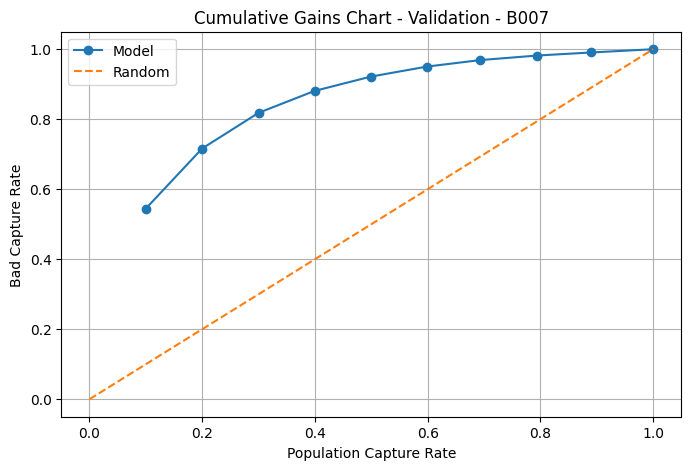

In [55]:
# Lift Chart - Validation

plt.figure(figsize=(8, 5))
plt.plot(
    val_gains["population_capture_rate"],
    val_gains["cum_bad_capture_rate"],
    marker="o",
    label="Model"
)
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

plt.title(f"Cumulative Gains Chart - Validation - {champion_model_number}")
plt.xlabel("Population Capture Rate")
plt.ylabel("Bad Capture Rate")
plt.legend()
plt.grid(True)
plt.show()

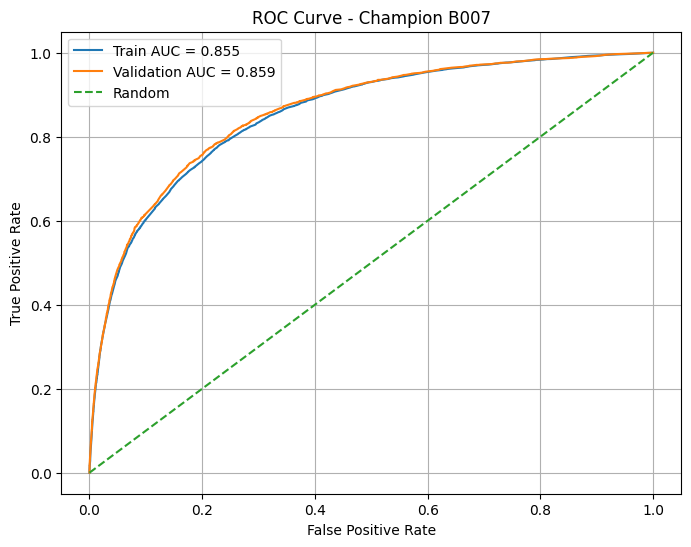

In [57]:
# ROC Curve

fpr_train, tpr_train, _ = roc_curve(y_train, p_train_champ)
fpr_val, tpr_val, _ = roc_curve(y_val, p_val_champ)

train_auc = roc_auc_score(y_train, p_train_champ)
val_auc = roc_auc_score(y_val, p_val_champ)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f"Train AUC = {train_auc:.3f}")
plt.plot(fpr_val, tpr_val, label=f"Validation AUC = {val_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

plt.title(f"ROC Curve - Champion {champion_model_number}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

In [58]:
# Full diagnostics package for champion model to be exported to Excel

champion_diagnostics_package = {
    "metadata": pd.DataFrame({
        "field": list(champion["metadata"].keys()),
        "value": list(champion["metadata"].values())
    }),
    "coefficients": champion["coefficients"],
    "diagnostics": champion["diagnostics"],
    "vif": champion["vif"],
    "validation_predicted_vs_actual": validation_pva_summary,
    "train_gains_lift": train_gains,
    "validation_gains_lift": val_gains
}

champion_excel_path = OUTPUT_DIR / f"{champion_model_number}_champion_diagnostics.xlsx"

with pd.ExcelWriter(champion_excel_path, engine="openpyxl") as writer:
    for sheet_name, table in champion_diagnostics_package.items():
        table.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("Saved:", champion_excel_path)

Saved: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs/B007_champion_diagnostics.xlsx


In [9]:
save_model_artifact(
    model_registry=model_registry,
    model_id="B007",  # replace with champion model number
    model_dir=MODEL_DIR,
    config_dir=CONFIG_DIR
)

Saved model: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs/saved_models/B007.joblib
Saved config: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs/model_configs/B007_config.json
